## Bibliotecas utilizadas

**Numpy**:
Tratamento otimizado de dados 

**Pandas:**
Extração de dados do Excel e tratamento de dados 

**Matplotlib:**
Criação de gráficos para a visualização de dados

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


---
# Extração dos dados

Para essa análise, utilizei um dataset público, disponível no Kaggle. Ele contém informações como:

- Tipo de conteúdo (imagem, carrosel, vídeo, etc);
- Tema abordado na publicação;
- Idioma e região de cada post;
- Data da publicação; 
- Insights de interações no post (views, likes, comentários, compartilhamentos)

🔗 Link: https://www.kaggle.com/datasets/svthejaswini/social-media-performance-and-engagement-data

In [120]:
df = pd.read_csv("../data/social_media_performance.csv")
df.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,1,LinkedIn,article,Technology,UR,BR,2025-04-25 09:47:00,#AI #Innovation #TechTrends #Programming #Codi...,0.76,37781,1202,462,185,0.0490,0
1,2,LinkedIn,poll,Health,FR,JP,2025-10-29 09:44:00,#Fitness #Nutrition #Wellness #Health #MentalH...,0.46,23541,1399,538,215,0.0915,1
2,3,LinkedIn,article,Travel,HI,FR,2025-02-10 14:12:00,#Travel #Journey #Adventure #Tourism #ExploreM...,-0.01,30714,1663,639,255,0.0833,1
3,4,LinkedIn,image,Sports,DE,DE,2025-04-18 22:41:00,#Cricket #Workout #Fitness,0.55,31294,1372,528,211,0.0675,0
4,5,LinkedIn,poll,Business,DE,US,2025-04-28 10:17:00,#Entrepreneur #Leadership #StartupLife,0.70,43129,2234,859,343,0.0797,0


Informações gerais sobre as colunas

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10000 non-null  int64  
 1   platform         10000 non-null  object 
 2   content_type     10000 non-null  object 
 3   topic            10000 non-null  object 
 4   language         10000 non-null  object 
 5   region           10000 non-null  object 
 6   post_datetime    10000 non-null  object 
 7   hashtags         10000 non-null  object 
 8   sentiment_score  10000 non-null  float64
 9   views            10000 non-null  int64  
 10  likes            10000 non-null  int64  
 11  comments         10000 non-null  int64  
 12  shares           10000 non-null  int64  
 13  engagement_rate  10000 non-null  float64
 14  is_viral         10000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 1.1+ MB



---
# Tratamento de dados

Aqui, realizei algumas modificações nos dados, com o objetivo de facilitar a interpretação das análises. 

## Criação de cópia do dataset original

In [122]:
df_analise = df.copy()

# renomeando colunas
df_analise.columns = ["id", "plataforma", "tipo_post", "topico", "idioma", "pais", "data", "hashtags", "sentimento", "visualizacoes", "likes", "comentarios", "compartilhamentos", "taxa_engajamento", "viral"]

# remoção de colunas não utilizadas na análise

df_analise = df_analise.drop(columns=["id", "pais", "sentimento", "taxa_engajamento"])
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   plataforma         10000 non-null  object
 1   tipo_post          10000 non-null  object
 2   topico             10000 non-null  object
 3   idioma             10000 non-null  object
 4   data               10000 non-null  object
 5   hashtags           10000 non-null  object
 6   visualizacoes      10000 non-null  int64 
 7   likes              10000 non-null  int64 
 8   comentarios        10000 non-null  int64 
 9   compartilhamentos  10000 non-null  int64 
 10  viral              10000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 859.5+ KB


## Informações sobre as colunas do dataset

- **plataforma**: plataforma em que o post foi divulgado 
- **tipo_post**: formato em que o conteúdo foi divulgado
- **topico**: assunto principal abordado pela publicação
- **idioma**: idioma em que o post foi escrito
- **data**: data de publicação 
- **hashtags**: hashtags adicionadas na postagem
- **visualizações**: quantidade total de visualizações
- **likes**: quantidade total de likes
- **comentários**: quantidade total de comentários
- **viral**: indica se o post viralizou ou não

## Criação da coluna "mes"

In [123]:
df_analise["data"] = pd.to_datetime(df_analise["data"])
df_analise["mes"] = df_analise["data"].apply(lambda d: f"{d.month:02d}")
df_analise["mes"] = df_analise["mes"].sort_values() 

# remoção da coluna "data"
df_analise = df_analise.drop(columns="data")

df_analise["mes"].unique()

array(['04', '10', '02', '07', '12', '05', '06', '03', '08', '11', '01',
       '09'], dtype=object)

## Função para mudança de meses para siglas

In [124]:
def meses_em_siglas(coluna: pd.Series) -> np.ndarray:
    dict_meses = {
        "01": 'Jan',
        "02": 'Fev',
        "03": 'Mar',
        "04": 'Abr',
        "05": 'Mai',
        "06": 'Jun',
        "07": 'Jul',
        "08": 'Ago',
        "09": 'Set',
        "10": 'Out',
        "11": 'Nov',
        "12": 'Dez'
    }
    return coluna.map(dict_meses).unique()

# teste da função

meses_em_siglas(df_analise["mes"])

array(['Abr', 'Out', 'Fev', 'Jul', 'Dez', 'Mai', 'Jun', 'Mar', 'Ago',
       'Nov', 'Jan', 'Set'], dtype=object)

## Tradução de dados

### Coluna "tipo_post"

In [125]:
dict_tipo_post = {
    "article": "Artigo",
    "story": "Story", 
    "video": "Vídeo",
    "image": "Imagem",
    "poll": "Enquete",
    "carousel": "Carrossel",
    "feed": "Feed",
    "reel": "Reel"}

df_analise["tipo_post"] = df_analise["tipo_post"].map(dict_tipo_post)
df_analise["tipo_post"]

0        Artigo
1       Enquete
2        Artigo
3        Imagem
4       Enquete
         ...   
9995      Vídeo
9996      Vídeo
9997      Vídeo
9998      Vídeo
9999      Vídeo
Name: tipo_post, Length: 10000, dtype: object

### Coluna "topicos"

In [126]:
dict_topicos = {"Entertainment": "Entretenimento",
                "Technology": "Tecnologia",
                "Business": "Negócios",
                "Sports": "Esportes",
                "Health": "Saúde",
                "Travel": "Viagem",
                "Food": "Comida",
                "Lifestyle": "Estilo de Vida",
                "Fashion": "Moda",
                "Education": "Educação",
}

df_analise["topico"] = df_analise["topico"].map(dict_topicos)

### Transformação da coluna "idioma" para interpretação mais fácil

In [127]:
dict_idiomas = {
    'HI': 'Hindi',
    'JA': 'Japonês',
    'DE': 'Alemão',
    'EN': 'Inglês',
    'UR': 'Urdu',
    'PT': 'Português',
    'ES': 'Espanhol',
    'FR': 'Francês'
}

df_analise["idioma"] = df_analise["idioma"].map(dict_idiomas)


---
# **Análise e Visualização de Dados**

### Configurações Matplotlib

In [128]:
plt.style.use("seaborn-v0_8-whitegrid")
COR_GRAFICO = "#009499"
COR_LEGENDA = "#303030"
TAMANHO_LEGENDA = 13

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## Análise Exploratória de Dados **(EDA)**

### Volume de posts por mês

In [129]:
quantidade_posts_mensal = df_analise["mes"].value_counts().sort_index()

meses = quantidade_posts_mensal.index
qtd_posts = quantidade_posts_mensal.values

quantidade_posts_mensal

mes
01    861
02    781
03    869
04    872
05    852
06    774
07    859
08    872
09    789
10    843
11    778
12    850
Name: count, dtype: int64

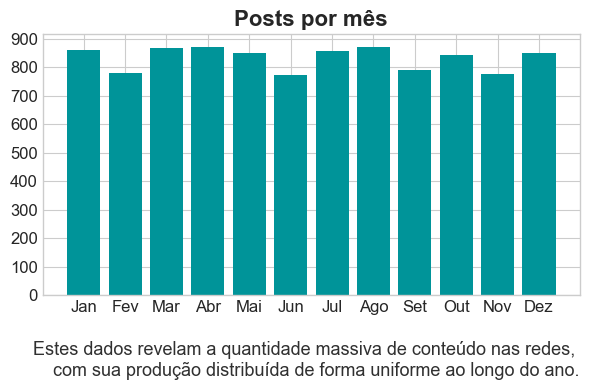

In [130]:
fig = plt.figure(figsize=(6, 4))
plt.bar(meses_em_siglas(meses), qtd_posts, color=COR_GRAFICO)
plt.yticks(np.arange(qtd_posts.max() + 100, step=100))
plt.xlabel("""
           Estes dados revelam a quantidade massiva de conteúdo nas redes, 
           com sua produção distribuída de forma uniforme ao longo do ano.""", loc="right", fontsize=TAMANHO_LEGENDA, color=COR_LEGENDA)

plt.title("Posts por mês", fontweight="bold")
plt.tight_layout()
plt.grid("on")

plt.savefig("../images/posts_por_mes.svg")
plt.show()

### Quantidade de posts por tipo de conteúdo

In [131]:
quantidade_posts_tipo = df_analise["tipo_post"].value_counts().sort_values()
tipo_post = quantidade_posts_tipo.index 
qtd_posts = quantidade_posts_tipo.values 

quantidade_posts_tipo

tipo_post
Feed          495
Reel          508
Enquete       525
Carrossel     944
Imagem        991
Artigo       1743
Story        1787
Vídeo        3007
Name: count, dtype: int64

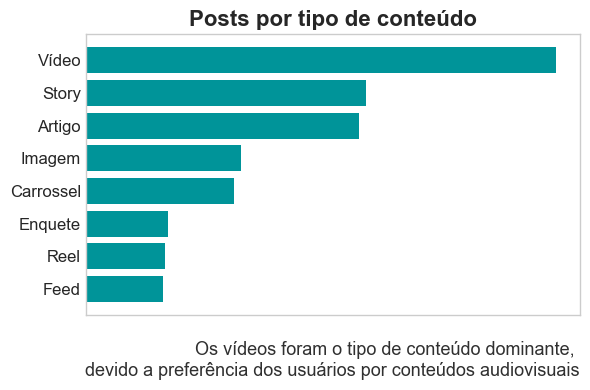

In [132]:
fig = plt.figure(figsize=(6, 4))
plt.barh(tipo_post, qtd_posts, color=COR_GRAFICO) 
plt.xticks([])
plt.xlabel("""
Os vídeos foram o tipo de conteúdo dominante, 
devido a preferência dos usuários por conteúdos audiovisuais""", loc="right", fontsize=TAMANHO_LEGENDA, color=COR_LEGENDA)

plt.title("Posts por tipo de conteúdo", fontweight="bold")
plt.tight_layout()
plt.grid(False)

plt.savefig("../images/posts_por_tipo_de_conteudo.svg")
plt.show()

### Quantidade de posts por idioma

In [133]:
quantidade_posts_idioma = df_analise["idioma"].value_counts().sort_values()
idiomas = quantidade_posts_idioma.index
qtd_por_idioma = quantidade_posts_idioma.values

Criação da figura

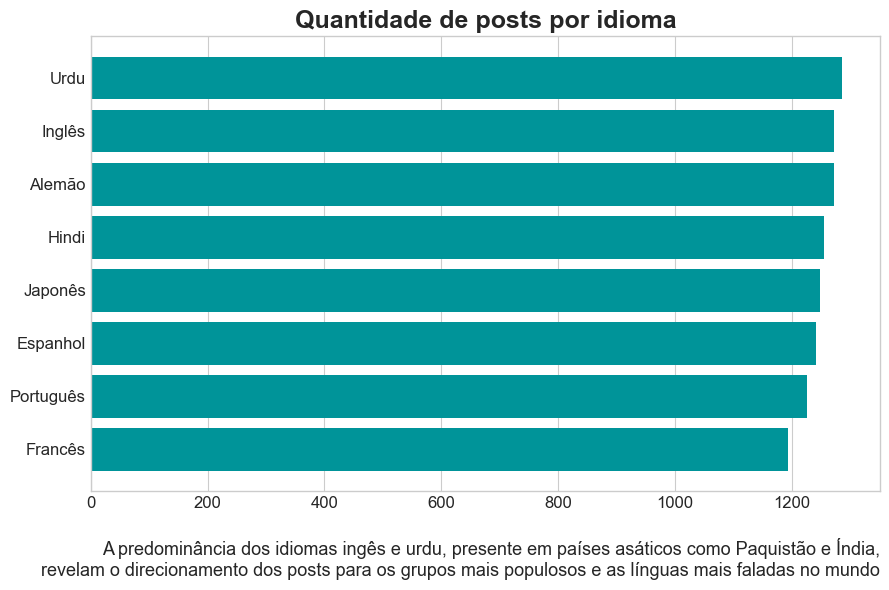

In [150]:
fig = plt.figure(figsize=(9, 6))
plt.barh(idiomas, qtd_por_idioma, color=COR_GRAFICO)
plt.xlabel("""
A predominância dos idiomas ingês e urdu, presente em países asáticos como Paquistão e Índia,
revelam o direcionamento dos posts para os grupos mais populosos e as línguas mais faladas no mundo""", loc="right", fontsize=TAMANHO_LEGENDA)

plt.title("Quantidade de posts por idioma", fontweight="bold", fontsize=18)
plt.tight_layout()
plt.grid(axis="y")

plt.savefig("../images/posts_por_idioma.svg")
plt.show()

### Quantidade de posts por tópico

In [135]:
quantidade_posts_topico = df_analise["topico"].value_counts().sort_values()

topicos = quantidade_posts_topico.index
qtd_posts = quantidade_posts_topico.values

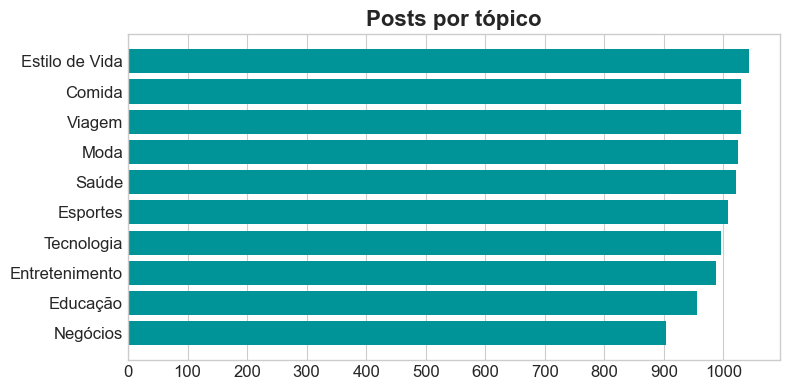

In [136]:
fig = plt.figure(figsize=(8, 4))

plt.barh(topicos, qtd_posts, color=COR_GRAFICO)
plt.xticks(np.arange(qtd_posts.max(), step=100))

plt.title("Posts por tópico", fontweight="bold")
plt.tight_layout()
plt.grid(axis="y")

plt.savefig("../images/posts_por_topico.svg")
plt.show()

### Hashtags mais utiilizadas

In [137]:
hashtags = {}
for hashtags_posts in df_analise["hashtags"]:
    array_hashtags = hashtags_posts.split(" ") 
    for item in array_hashtags:
        if item not in hashtags:
            hashtags[item] = 0
        else:
            hashtags[item] += 1

In [138]:
ranking_hashtags = dict(sorted(hashtags.items(), key=lambda valor: valor[1], reverse=True))
top_hashtags = list(ranking_hashtags.keys())[0:10]

In [139]:
print("Hashtags mais utilizadas:\n")
for (indice, hashtag) in enumerate(top_hashtags):
    print(f"{indice + 1}º - {hashtag}")

Hashtags mais utilizadas:

1º - #Wellness
2º - #Fitness
3º - #Food
4º - #Positivity
5º - #Motivation
6º - #DailyLife
7º - #MindfulLiving
8º - #Travel
9º - #MustTry
10º - #Lifestyle


Logo, as hashtags confirmam que temas relacionados a saúde, estilo de vida e bem estar são os mais consumidos nas redes.

### Quantidade de insights por plataforma 

#### Insights gerais

Likes

In [140]:
qtd_likes = df_analise["likes"].sum()
print(f"Quantidade total de likes = {qtd_likes:_}")

Quantidade total de likes = 152_368_747


Comentários

In [141]:
qtd_comentarios = df_analise["comentarios"].sum()
print(f"Quantidade total de comentarios = {qtd_comentarios:_}")

Quantidade total de comentarios = 58_601_396


Visualizações

In [142]:
qtd_visualizacoes = df_analise["visualizacoes"].sum()
print(f"Quantidade total de visualizacoes = {qtd_visualizacoes:_}")

Quantidade total de visualizacoes = 2_121_421_581


Array com os labels utilizados para as visualizações

In [143]:
label_insights = ["Likes", "Comentários", "Visualizações"]

#### Youtube

In [144]:
youtube = df_analise.loc[df_analise["plataforma"] == "YouTube"]
qtd_likes_youtube = youtube["likes"].sum()
qtd_comentarios_youtube = youtube["comentarios"].sum()
qtd_visualizacoes_youtube = youtube["visualizacoes"].sum()

insights_youtube = np.array([qtd_likes_youtube, qtd_comentarios_youtube, qtd_visualizacoes_youtube])

for i, valor in enumerate(insights_youtube):
    print(f"{label_insights[i]}: {valor:_}")

Likes: 75_525_196
Comentários: 29_047_670
Visualizações: 1_290_079_109


#### Medium

In [145]:
medium = df_analise.loc[df_analise["plataforma"] == "Medium"]
qtd_likes_medium = medium["likes"].sum()
qtd_comentarios_medium = medium["comentarios"].sum()
qtd_visualizacoes_medium = medium["visualizacoes"].sum()

insights_medium = np.array([qtd_likes_medium, qtd_comentarios_medium, qtd_visualizacoes_medium])

for i, valor in enumerate(insights_medium):
    print(f"{label_insights[i]}: {valor:_}")

Likes: 10_729_289
Comentários: 4_126_155
Visualizações: 124_834_876


#### LinkedIn

In [146]:
linkedin = df_analise.loc[df_analise["plataforma"] == "LinkedIn"]
qtd_likes_linkedin = linkedin["likes"].sum()
qtd_comentarios_linkedin = linkedin["comentarios"].sum()
qtd_visualizacoes_linkedin = linkedin["visualizacoes"].sum()

insights_linkedin = np.array([qtd_likes_linkedin, qtd_comentarios_linkedin, qtd_visualizacoes_linkedin])

for i, valor in enumerate(insights_linkedin):
    print(f"{label_insights[i]}: {valor:_}")

Likes: 3_313_735
Comentários: 1_274_024
Visualizações: 64_533_409


#### Instagram

In [147]:
instagram = df_analise.loc[df_analise["plataforma"] == "Instagram"]
qtd_likes_instagram = instagram["likes"].sum()
qtd_comentarios_instagram = instagram["comentarios"].sum()
qtd_visualizacoes_instagram = instagram["visualizacoes"].sum()

insights_instagram = np.array([qtd_likes_instagram, qtd_comentarios_instagram, qtd_visualizacoes_instagram])

for i, valor in enumerate(insights_instagram):
    print(f"{label_insights[i]}: {valor:_}")

Likes: 62_800_527
Comentários: 24_153_547
Visualizações: 641_974_187


### Volume de posts virais

In [148]:
quantidade_posts_virais = df_analise[df_analise["viral"] == 0]["viral"].count()
porcentagem_posts_virais = (quantidade_posts_virais / df_analise.shape[0]) * 100

print(f"Quantidade de posts virais: {quantidade_posts_virais}")
print(f"Porcentagem em relação ao total: {porcentagem_posts_virais:.2f}%")

Quantidade de posts virais: 4543
Porcentagem em relação ao total: 45.43%
